In [ ]:
### Plotting precipitation 

In [1]:
import xarray as xr
Bellinzona_Combiprecip = xr.open_dataset( "/storage/homefs/ge24z347/Zell_event/Data_forprocess/Combiprecip/cpch_bellinzona_giubiasco_ti_2021_2021-08-05-2021-08-07.nc")
Bellinzona_Combiprecip

<xarray.Dataset> Size: 131MB
Dimensions:  (y: 640, x: 710, time: 72)
Coordinates:
  * y        (y) int64 5kB 840500 841500 842500 ... 1477500 1478500 1479500
  * x        (x) int64 6kB 2255500 2256500 2257500 ... 2962500 2963500 2964500
  * time     (time) datetime64[ns] 576B 2021-08-05 ... 2021-08-07T23:00:00
Data variables:
    RR       (y, x, time) float32 131MB ...
Attributes:
    source:   Requested from https://hub.meteoswiss.ch on the 2026-01-28 10:3...
    crs:      EPSG:2056

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
from pathlib import Path
import rasterio
import geopandas as gpd
from shapely.geometry import box

import requests
from PIL import Image
from io import BytesIO

# --------------------------------------------------
# INPUTS
# --------------------------------------------------
nc_file = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/Combiprecip/cpch_bellinzona_giubiasco_ti_2021_2021-08-05-2021-08-07.nc"
dem_file = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Bellinzona_2m_accv5/Bellinzona_2m_accv5.dem"
catchment_file = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/geo_ezgg_40km.gpkg"

# For Agno:
var_name = "RR"
time_coord = "time"

out_dir = Path("/storage/homefs/ge24z347/Zell_event/AGNO_PLOTS/Combiprecip_Agno_2m_precipitation")
out_dir.mkdir(exist_ok=True)

# QGIS extent (EPSG:2056)
plot_extent = (2708347.422, 1108803.535, 2733766.610, 1132865.160)   # xmin, xmax, ymin, ymax
xmin, xmax, ymin, ymax = plot_extent

# Exact times
times_exact = np.array([
    "2021-08-07T13:00:00",
    "2021-08-07T14:00:00",
    "2021-08-07T15:00:00",
    "2021-08-07T16:00:00",
    "2021-08-07T17:00:00",
    "2021-08-07T18:00:00",
    "2021-08-07T19:00:00",
    "2021-08-07T20:00:00",
    "2021-08-07T21:00:00",
    "2021-08-07T22:00:00",
    "2021-08-07T23:00:00",
], dtype="datetime64[ns]")

# Swisstopo WMS layer
wms_layer = "ch.swisstopo.swisstlm3d-karte-grau"

precip_alpha = 0.70
wms_start_resolution_m = 2
wms_max_pixels = 40_000_000
save_dpi = 400

# --------------------------------------------------
# Robust WMS fetch (auto-coarsen if image would be huge)
# --------------------------------------------------
def get_swisstopo_background_image(
    xmin, xmax, ymin, ymax,
    resolution_m=2,
    layer="ch.swisstopo.swisstlm3d-karte-grau",
    max_pixels=10_000_000
):
    xmin, xmax = float(min(xmin, xmax)), float(max(xmin, xmax))
    ymin, ymax = float(min(ymin, ymax)), float(max(ymin, ymax))
    dx, dy = xmax - xmin, ymax - ymin

    res = float(resolution_m)
    while True:
        width_px = int(np.ceil(dx / res))
        height_px = int(np.ceil(dy / res))
        if width_px * height_px <= max_pixels:
            break
        res *= 2

    bbox = f"{xmin},{ymin},{xmax},{ymax}"
    params = {
        "SERVICE": "WMS",
        "REQUEST": "GetMap",
        "VERSION": "1.3.0",
        "LAYERS": layer,
        "BBOX": bbox,
        "CRS": "EPSG:2056",
        "WIDTH": width_px,
        "HEIGHT": height_px,
        "FORMAT": "image/png",
        "TRANSPARENT": "TRUE",
    }
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "image/png,image/*,*/*;q=0.8"
    }

    r = requests.get("https://wms.geo.admin.ch/", params=params, headers=headers, timeout=60)
    if r.status_code != 200:
        print("Failed to fetch WMS:", r.status_code)
        return None, res

    ctype = r.headers.get("Content-Type", "")
    if "image" not in ctype.lower():
        print("WMS returned non-image content:", ctype)
        print(r.text[:250])
        return None, res

    return Image.open(BytesIO(r.content)).convert("RGBA"), res


# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
ds = xr.open_dataset(nc_file, decode_times=True)

print("Variables in dataset:", list(ds.data_vars))
print("Coordinates in dataset:", list(ds.coords))

print("Coordinate uniqueness:")
print(f"  time unique: {ds.indexes[time_coord].is_unique}")
print(f"  x unique:    {ds.indexes['x'].is_unique}")
print(f"  y unique:    {ds.indexes['y'].is_unique}")

# Remove duplicated time values if needed
if not ds.indexes[time_coord].is_unique:
    _, unique_idx = np.unique(ds[time_coord].values, return_index=True)
    ds = ds.isel({time_coord: np.sort(unique_idx)})
    print(f"Removed duplicate time entries. New time length: {ds.sizes[time_coord]}")

da = ds[var_name]

# --------------------------------------------------
# READ DEM BOUNDS
# --------------------------------------------------
with rasterio.open(dem_file) as src:
    dem_left, dem_bottom, dem_right, dem_top = src.bounds

print("DEM bounds:")
print(f"left={dem_left}, right={dem_right}, bottom={dem_bottom}, top={dem_top}")

# --------------------------------------------------
# LOAD CATCHMENT
# --------------------------------------------------
catchment_gdf = gpd.read_file(catchment_file)

if catchment_gdf.crs is None:
    raise ValueError("Catchment file has no CRS. Please define it first.")

if catchment_gdf.crs.to_string() != "EPSG:2056":
    catchment_gdf = catchment_gdf.to_crs("EPSG:2056")

# optional clip to plotting window for faster drawing
bbox_geom = box(xmin, ymin, xmax, ymax)

# First try gpd.clip, and if that fails use intersects fallback
try:
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs="EPSG:2056")
    catchment_plot = gpd.clip(catchment_gdf, bbox_gdf)
except Exception as e:
    print("gpd.clip failed, using intersects fallback.")
    print("Reason:", e)
    catchment_plot = catchment_gdf[catchment_gdf.intersects(bbox_geom)]

print("Catchment features loaded:", len(catchment_gdf))
print("Catchment features in plot window:", len(catchment_plot))

# --------------------------------------------------
# SPATIAL SUBSET
# --------------------------------------------------
x_ascending = bool(da.x.values[0] < da.x.values[-1])
y_ascending = bool(da.y.values[0] < da.y.values[-1])

x_slice = slice(xmin, xmax) if x_ascending else slice(xmax, xmin)
y_slice = slice(ymin, ymax) if y_ascending else slice(ymax, ymin)

da_space = da.sel(x=x_slice, y=y_slice)

print("Subset shape after spatial selection:", da_space.shape)

if da_space.sizes["x"] == 0 or da_space.sizes["y"] == 0:
    raise ValueError("Spatial subset is empty. Check plot_extent vs NetCDF coordinates.")

# extent from actual selected raster coordinates
xvals = da_space.x.values
yvals = da_space.y.values
data_extent = (float(xvals.min()), float(xvals.max()), float(yvals.min()), float(yvals.max()))

# --------------------------------------------------
# TIME SUBSET (safe selection)
# --------------------------------------------------
available_times = da_space[time_coord].values
common_times = np.intersect1d(available_times, times_exact)

if len(common_times) == 0:
    raise ValueError("None of the requested times were found in the dataset.")

missing_times = np.setdiff1d(times_exact, available_times)
if len(missing_times) > 0:
    print("These requested times were NOT found and will be skipped:")
    print(missing_times)

da_sel = da_space.sel({time_coord: common_times})

print("Selected times:")
print(da_sel[time_coord].values)

# --------------------------------------------------
# DISCRETE "RADAR-LIKE" LEVELS
# --------------------------------------------------
levels_full = np.array(
    [0.1, 0.2, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 80, 100, 130, 160, 250, 350],
    dtype=float
)

vmax = float(np.nanmax(da_sel.values))
if not np.isfinite(vmax) or vmax <= 0:
    raise ValueError("No positive precipitation values in the selected extent/times.")

levels = levels_full[levels_full <= max(1.0, vmax)]
if len(levels) < 2:
    levels = np.array([0.1, max(1.0, vmax)])

if levels[-1] < vmax:
    higher_levels = levels_full[levels_full > levels[-1]]
    if len(higher_levels) > 0:
        levels = np.append(levels, higher_levels[0])
    else:
        levels = np.append(levels, vmax)

mswiss_15 = [
    "#F9844A", "#FBB476", "#FDD8A3",
    "#FFFFCC", "#F0E68C",
    "#C7E9B4", "#7FCDBB",
    "#41B6C4", "#1D91C0",
    "#225EA8", "#253494",
    "#081D58", "#31183b",
    "#70265c", "#bc3754"
]

n_bins = len(levels) - 1
base = plt.get_cmap(ListedColormap(mswiss_15))
colors = base(np.linspace(0, 1, n_bins))
cmap = ListedColormap(colors)
cmap.set_bad((0, 0, 0, 0))
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

print(f"vmax in window: {vmax:.2f} mm")
print("levels used:", levels)

# --------------------------------------------------
# GET BACKGROUND ONCE
# --------------------------------------------------
bg_img, used_res = get_swisstopo_background_image(
    xmin, xmax, ymin, ymax,
    resolution_m=wms_start_resolution_m,
    layer=wms_layer,
    max_pixels=wms_max_pixels
)
print(f"WMS resolution used: {used_res} m/px")

# --------------------------------------------------
# LOCATION MARKER
# --------------------------------------------------
# Replace with Agno coordinates if needed
location_x = 2713681.093
location_y = 1094818.636
location_name = "Agno"

# --------------------------------------------------
# PLOT
# --------------------------------------------------
for t in da_sel[time_coord].values:
    frame = da_sel.sel({time_coord: t}).astype(float)
    frame = frame.where(frame > 0)

    fig, ax = plt.subplots(figsize=(8, 7))
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    # Background
    if bg_img is not None:
        ax.imshow(bg_img, extent=(xmin, xmax, ymin, ymax), origin="upper", zorder=0)
    else:
        print("No WMS background for", t)

    # Precipitation
    im = ax.imshow(
        frame.values,
        extent=data_extent,
        origin="lower",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        alpha=precip_alpha,
        zorder=2
    )

    # Catchment outline
    if len(catchment_plot) > 0:
        catchment_plot.boundary.plot(
            ax=ax,
            edgecolor="black",
            linewidth=1.2,
            zorder=4
        )

    # DEM rectangle
    rect = Rectangle(
        (dem_left, dem_bottom),
        dem_right - dem_left,
        dem_top - dem_bottom,
        fill=False,
        edgecolor="red",
        linewidth=2.0,
        zorder=5
    )
    ax.add_patch(rect)

    # Location marker
    ax.scatter(
        location_x,
        location_y,
        marker="^",
        s=50,
        edgecolor="black",
        facecolor="yellow",
        linewidth=1.5,
        zorder=6
    )

    ax.text(
        location_x + 500,
        location_y + 500,
        location_name,
        fontsize=8,
        color="black",
        weight="bold",
        zorder=6
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(str(np.datetime64(t))[:16], color="black")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=levels)
    cbar.set_label("precipitation (mm)")
    cbar.ax.tick_params(colors="black")
    cbar.outline.set_edgecolor("black")

    out = out_dir / f"RR_AGNO_{str(t)[:19].replace(':','')}.png"
    plt.savefig(out, dpi=save_dpi, transparent=True, bbox_inches="tight")
    plt.close()

print("Done. Saved to:", out_dir)

Variables in dataset: ['RR']
Coordinates in dataset: ['y', 'x', 'time']
Coordinate uniqueness:
  time unique: False
  x unique:    True
  y unique:    True
Removed duplicate time entries. New time length: 97
DEM bounds:
left=2710000.0, right=2716000.0, bottom=1092000.0, top=1102000.0
Catchment features loaded: 1193
Catchment features in plot window: 20
Subset shape after spatial selection: (15, 16, 97)
Selected times:
['2022-09-07T18:00:00.000000000' '2022-09-07T19:00:00.000000000'
 '2022-09-07T20:00:00.000000000' '2022-09-07T21:00:00.000000000'
 '2022-09-07T22:00:00.000000000' '2022-09-07T23:00:00.000000000'
 '2022-09-08T00:00:00.000000000' '2022-09-08T01:00:00.000000000'
 '2022-09-08T02:00:00.000000000' '2022-09-08T03:00:00.000000000'
 '2022-09-08T04:00:00.000000000' '2022-09-08T05:00:00.000000000'
 '2022-09-08T06:00:00.000000000' '2022-09-08T07:00:00.000000000'
 '2022-09-08T08:00:00.000000000' '2022-09-08T09:00:00.000000000'
 '2022-09-08T10:00:00.000000000' '2022-09-08T11:00:00.0000

In [ ]:
## plotting the hytograph of the event 

Rain values:
[2.8333333e-03 1.5666662e-02 9.4299994e+00 4.0946667e+01 1.2631667e+01
 9.5900011e+00 2.9116663e+01 2.5195007e+01 2.2694998e+01 9.7116661e+00
 2.1338332e+00 3.6486661e+00 3.0886667e+00 0.0000000e+00]
Cumulative rainfall:
[2.83333333e-03 1.84999947e-02 9.44849968e+00 5.03951645e+01
 6.30268326e+01 7.26168365e+01 1.01733498e+02 1.26928505e+02
 1.49623505e+02 1.59335175e+02 1.61469009e+02 1.65117676e+02
 1.68206345e+02 1.68206345e+02]


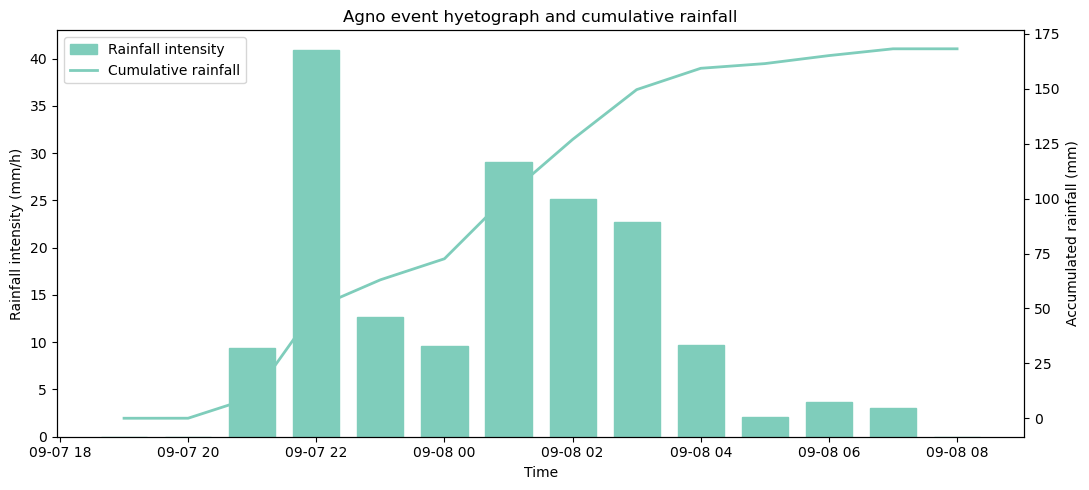

Saved to: /storage/homefs/ge24z347/Zell_event/AGNO_PLOTS/hyetograph/agno_event_hyetograph_cumulative.png


In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# INPUTS
# --------------------------------------------------
nc_file = "/storage/homefs/ge24z347/Zell_event/Data_forprocess/Combiprecip/cpch_agno_ti_2022_2022-09-05-2022-09-08.nc"
var_name = "RR"
time_coord = "time"

xmin, xmax = 2710400, 2716000
ymin, ymax = 1092500, 1101700

t_start = np.datetime64("2022-09-07T19:00:00")
t_end   = np.datetime64("2022-09-08T08:00:00")

out_dir = Path("/storage/homefs/ge24z347/Zell_event/AGNO_PLOTS/hyetograph")
out_dir.mkdir(exist_ok=True)

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
ds = xr.open_dataset(nc_file, decode_times=True)
da = ds[var_name]

# --------------------------------------------------
# SPATIAL SUBSET
# --------------------------------------------------
x_ascending = bool(da.x.values[0] < da.x.values[-1])
y_ascending = bool(da.y.values[0] < da.y.values[-1])

x_slice = slice(xmin, xmax) if x_ascending else slice(xmax, xmin)
y_slice = slice(ymin, ymax) if y_ascending else slice(ymax, ymin)

da_space = da.sel(x=x_slice, y=y_slice)

if da_space.sizes["x"] == 0 or da_space.sizes["y"] == 0:
    raise ValueError("Spatial subset is empty. Check extent.")

# --------------------------------------------------
# TIME SUBSET
# --------------------------------------------------
da_sel = da_space.sel({time_coord: slice(t_start, t_end)})

if da_sel.sizes[time_coord] == 0:
    raise ValueError("No data in selected time window.")

# --------------------------------------------------
# AREAL MEAN HYETOGRAPH
# --------------------------------------------------
hyeto = da_sel.mean(dim=("y", "x"), skipna=True)

times = hyeto[time_coord].values
rain = hyeto.values

# cumulative rainfall
cum_rain = np.cumsum(rain)

print("Rain values:")
print(rain)
print("Cumulative rainfall:")
print(cum_rain)

# --------------------------------------------------
# PLOT: hyetograph + cumulative rainfall
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 5))

plot_color = "#7FCDBB"

# Hyetograph bars
ax1.bar(
    times,
    rain,
    width=0.03,
    color=plot_color,
    edgecolor=plot_color,
    label="Rainfall intensity"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Rainfall intensity (mm/h)")
ax1.grid(False)

# Cumulative rainfall on second axis
ax2 = ax1.twinx()
ax2.plot(
    times,
    cum_rain,
    linewidth=2,
    color=plot_color,
    label="Cumulative rainfall"
)
ax2.set_ylabel("Accumulated rainfall (mm)")
ax2.grid(False)

# Title
ax1.set_title("Agno event hyetograph and cumulative rainfall")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()

out_png = out_dir / "agno_event_hyetograph_cumulative.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

print("Saved to:", out_png)